## Phase II

### Importing Required Python Libraries

In [14]:
import numpy as np
import pandas as pd
import statistics
import re
from sqlalchemy import create_engine

### Importing the files

In [3]:
election_results_1951_2019 = pd.read_csv("RawData/election_results_1951_2019.csv")
loksabha_1962_2019 = pd.read_csv('RawData/loksabha_1962-2019.csv')
election_results_2024 = pd.read_csv('rawdata/election_results_2024.csv')
ref_party_master_1962_2021 = pd.read_csv('rawdata/ref_party_master_1962_2021.csv')
election_constituency_summary = pd.read_csv('rawdata/election_constituency_summary.csv')
socio_literacy_1951_2011 = pd.read_csv('rawdata/socio_literacy_1951_2011.csv')

### 2024 Data Alignment & Append

### 1. RENAME COLUMNS TO MATCH MASTER SCHEMA

In [17]:
# We change the 2024 specific names to the standardized names in your 'election_master' table
# 1. Define the "Master List" of columns that exist in your MySQL table
master_columns = [
    'id', 'state', 'constitution', 'election_year', 'candidate', 'gender', 
    'party', 'age', 'category', 'votes_received', 'votes_received_perc', 
    'num_seats', 'state_pc_year', 'rank', 'result', 'year_int', 
    'state_upper', 'standardized_state', 'parent_state', 'is_winner', 'is_multimember'
]

# 2. Rename the 2024 columns we actually need
election_results_2024_cleaned = election_results_2024.rename(columns={
    'State': 'state',
    'PC Name': 'constitution',
    'Candidate': 'candidate',
    'Party': 'party',
    'Total Votes': 'votes_received',
    'Vote Share': 'votes_received_perc',
    'Sl no': 'rank'
})

### 2. ADD TEMPORAL & CATEGORICAL CONSTANTS

In [18]:
election_results_2024_cleaned['year_int'] = 2024
election_results_2024_cleaned['election_year'] = "2024 (18th LOK SABHA)"
election_results_2024_cleaned['gender'] = "UNKNOWN"
election_results_2024_cleaned['age'] = 0.0
election_results_2024_cleaned['category'] = "GENERAL"
election_results_2024_cleaned['num_seats'] = 1
election_results_2024_cleaned['is_multimember'] = 0
election_results_2024_cleaned['is_winner'] = (election_results_2024_cleaned['rank'] == 1).astype(int)
election_results_2024_cleaned['result'] = election_results_2024_cleaned['rank'].apply(lambda x: 'winner' if x == 1 else 'loser')

### 3. CLEAN NUMERIC COLUMNS

In [19]:
election_results_2024_cleaned['votes_received'] = pd.to_numeric(
    election_results_2024_cleaned['votes_received'].astype(str).str.replace(',', ''), errors='coerce'
).fillna(0).astype(int)

election_results_2024_cleaned['votes_received_perc'] = pd.to_numeric(
    election_results_2024_cleaned['votes_received_perc'].astype(str).str.replace('%', ''), errors='coerce'
).fillna(0).astype(float)

### 4. GEOGRAPHIC STANDARDIZATION

In [20]:
election_results_2024_cleaned['state_upper'] = election_results_2024_cleaned['state'].str.upper().str.strip()
election_results_2024_cleaned['standardized_state'] = election_results_2024_cleaned['state_upper']
election_results_2024_cleaned['parent_state'] = election_results_2024_cleaned['standardized_state']
election_results_2024_cleaned['state_pc_year'] = (
    election_results_2024_cleaned['state'] + "-" + 
    election_results_2024_cleaned['constitution'] + "-" + 
    election_results_2024_cleaned['election_year']
)

### 5. CREATE COMPOSITE JOIN KEY

In [21]:
election_results_2024_cleaned['id'] = range(89841, 89841 + len(election_results_2024_cleaned))
# This tells Python: "Only keep the columns that are in our master_columns list"
final_2024_to_push = election_results_2024_cleaned[master_columns]

In [22]:
final_2024_to_push.head(5)

,id,state,constitution,election_year,candidate,gender,party,age,category,votes_received,...,num_seats,state_pc_year,rank,result,year_int,state_upper,standardized_state,parent_state,is_winner,is_multimember
0,89841,Andhra Pradesh,Araku (ST),2024 (18th LOK SABHA),GUMMA THANUJA RANI,UNKNOWN,Yuvajana Sramika Rythu Congress Party,0.0,GENERAL,477005,...,1,Andhra Pradesh-Araku (ST)-2024 (18th LOK SABHA),1,winner,2024,ANDHRA PRADESH,ANDHRA PRADESH,ANDHRA PRADESH,1,0
1,89842,Andhra Pradesh,Araku (ST),2024 (18th LOK SABHA),KOTHAPALLI GEETHA,UNKNOWN,Bharatiya Janata Party,0.0,GENERAL,426425,...,1,Andhra Pradesh-Araku (ST)-2024 (18th LOK SABHA),2,loser,2024,ANDHRA PRADESH,ANDHRA PRADESH,ANDHRA PRADESH,0,0
2,89843,Andhra Pradesh,Araku (ST),2024 (18th LOK SABHA),APPALANARASA PACHIPENTA,UNKNOWN,Communist Party of India (Marxist),0.0,GENERAL,123129,...,1,Andhra Pradesh-Araku (ST)-2024 (18th LOK SABHA),3,loser,2024,ANDHRA PRADESH,ANDHRA PRADESH,ANDHRA PRADESH,0,0
3,89844,Andhra Pradesh,Araku (ST),2024 (18th LOK SABHA),AVASHYA LAHARI . VARAM,UNKNOWN,Bahujan Samaj Party,0.0,GENERAL,25750,...,1,Andhra Pradesh-Araku (ST)-2024 (18th LOK SABHA),4,loser,2024,ANDHRA PRADESH,ANDHRA PRADESH,ANDHRA PRADESH,0,0
4,89845,Andhra Pradesh,Araku (ST),2024 (18th LOK SABHA),SAMAREDDY BALAKRISHNA,UNKNOWN,Independent,0.0,GENERAL,9535,...,1,Andhra Pradesh-Araku (ST)-2024 (18th LOK SABHA),5,loser,2024,ANDHRA PRADESH,ANDHRA PRADESH,ANDHRA PRADESH,0,0


In [23]:
# 7. APPEND TO MYSQL
engine = create_engine('mysql+mysqlconnector://root@localhost/election_db')

final_2024_to_push.to_sql(
    name='election_master', 
    con=engine, 
    if_exists='append', 
    index=False,
    chunksize=1000
)

8902

---

# Using reference dataframe - loksabha_1962 - 2019

In [ ]:
# 1. CLEAN THE ELECTORS COLUMN
# Removing commas so "1,23,456" becomes the number 123456
loksabha_1962_2019['electors_clean'] = pd.to_numeric(
    loksabha_1962_2019['electors'].astype(str).str.replace(',', ''), errors='coerce'
).fillna(0).astype(int)

# Renaming 'Pc_name' to match with SQL table column 'constitution'
loksabha_1962_2019['constitution_upper'] = loksabha_1962_2019['Pc_name'].str.upper().str.strip()

In [27]:
# Re-defining the translation dictionary for the new notebook session
state_standardization_map = {
    # Spelling & Case Variations
    'ORISSA': 'ODISHA',
    'PONDICHERRY': 'PUDUCHERRY',
    'UTTARANCHAL': 'UTTARAKHAND',
    'UTTARKHAND': 'UTTARAKHAND',
    'CHATTISGARH': 'CHHATTISGARH',
    'NATIONAL CAPITAL TERRITORY OF DELHI': 'DELHI',
    'LACCADIVE, MINICOY AND AMINDIVI ISLANDS': 'LAKSHADWEEP',
    
    # Historical Reorganizations (1951-1956 Era)
    'HYDERABAD': 'TELANGANA', 
    'BOMBAY': 'MAHARASHTRA',  
    'MYSORE': 'KARNATAKA',
    'MADRAS': 'TAMIL NADU',
    'TRAVANCORE COCHIN': 'KERALA',
    'SAURASHTRA': 'GUJARAT',
    'KUTCH': 'GUJARAT',
    'MADHYA BHARAT': 'MADHYA PRADESH',
    'VINDHYA PRADESH': 'MADHYA PRADESH',
    'BHOPAL': 'MADHYA PRADESH',
    'AJMER': 'RAJASTHAN',
    'COORG': 'KARNATAKA',
    'PATIALA AND EAST PUNJ': 'PUNJAB',
    'GOA DAMAN AND DIU': 'GOA' 
}

In [ ]:
# 2. ALIGN TEMPORAL DATA
# Converting 1962.0 (float) to 1962 (int) to match year_int column
loksabha_1962_2019['year_int'] = loksabha_1962_2019['year'].fillna(0).astype(int)

In [28]:
# 3. STANDARDIZE GEOGRAPHY
# 1. Clean the 'state' strings (Upper case and remove extra spaces)
loksabha_1962_2019['state_upper'] = loksabha_1962_2019['state'].str.upper().str.strip()

# 2. Apply the map to create the 'standardized_state' column
loksabha_1962_2019['standardized_state'] = loksabha_1962_2019['state_upper'].replace(state_standardization_map)

# 3. Quick Check: How many unique states do we have now?
print(f"Unique states after standardization: {loksabha_1962_2019['standardized_state'].nunique()}")

Unique states after standardization: 43


In [30]:
# Create the standardized column for your historical data in THIS notebook
election_results_1951_2019['state_upper'] = election_results_1951_2019['state'].str.upper().str.strip()
election_results_1951_2019['standardized_state'] = election_results_1951_2019['state_upper'].replace(state_standardization_map)

print("Standardized column created for 1951-2019 data. Ready for audit!")

Standardized column created for 1951-2019 data. Ready for audit!


In [ ]:
# 1. Remove commas and extra whitespace to make the match more flexible
loksabha_1962_2019['standardized_state'] = (
    loksabha_1962_2019['standardized_state']
    .str.replace(',', '', regex=False)
    .str.strip()
)

# 2. Re-apply the map to catch 'GOA DAMAN AND DIU'
loksabha_1962_2019['standardized_state'] = (
    loksabha_1962_2019['standardized_state']
    .replace(state_standardization_map)
)

# 3. Final Audit
master_states = set(election_results_1951_2019['standardized_state'].unique())
file_states = set(loksabha_1962_2019['standardized_state'].unique())
mismatches = file_states - master_states

if not mismatches:
    print("All states match the Master Table.")
else:
    print(f"missing: {mismatches}")

✅ Perfect! All states now match the Master Table. You have a unified geography.


In [36]:
# Displaying all unique states to spot any remaining "twins"
unique_states = loksabha_1962_2019['standardized_state'].unique()
unique_states.sort()
print(unique_states)

# Check for a specific mismatch:
# Do any names in this file NOT exist in your master database?
# (Assuming 'election_results_1951_2019' is loaded in this notebook)
master_states = set(election_results_1951_2019['standardized_state'].unique())
file_states = set(unique_states)

mismatches = file_states - master_states
if mismatches:
    print(f"These states are in the 1962-2019 file but NOT in the Master Table: {mismatches}")
else:
    print("All states match the Master Table.")

['ANDAMAN AND NICOBAR ISLANDS' 'ANDHRA PRADESH' 'ARUNACHAL PRADESH'
 'ASSAM' 'BIHAR' 'CHANDIGARH' 'CHHATTISGARH' 'DADRA AND NAGAR HAVELI'
 'DAMAN AND DIU' 'DELHI' 'GOA' 'GUJARAT' 'HARYANA' 'HIMACHAL PRADESH'
 'JAMMU AND KASHMIR' 'JHARKHAND' 'KARNATAKA' 'KERALA' 'LAKSHADWEEP'
 'MADHYA PRADESH' 'MAHARASHTRA' 'MANIPUR' 'MEGHALAYA' 'MIZORAM' 'NAGALAND'
 'ODISHA' 'PUDUCHERRY' 'PUNJAB' 'RAJASTHAN' 'SIKKIM' 'TAMIL NADU'
 'TELANGANA' 'TRIPURA' 'UTTAR PRADESH' 'UTTARAKHAND' 'WEST BENGAL']
All states match the Master Table.


### Creating the Elector lookup table

In [37]:
# 1. Standardize Constituency names for a perfect match
loksabha_1962_2019['constitution_clean'] = loksabha_1962_2019['Pc_name'].str.upper().str.strip()

# 2. Select only the necessary columns
# We use year_int because it is a clean number in both tables
elector_lookup = loksabha_1962_2019[[
    'standardized_state', 
    'constitution_clean', 
    'year_int', 
    'electors_clean'
]].drop_duplicates()

# 3. Quick check of the lookup size
print(f"Lookup table created with {len(elector_lookup)} unique constituency-years.")

Lookup table created with 8046 unique constituency-years.


### Push the Lookup to MySQL

In [38]:
# Upload the lookup table to a temporary table in your database
elector_lookup.to_sql(
    name='temp_electors', 
    con=engine, 
    if_exists='replace', 
    index=False
)
print("Temporary electors table pushed to MySQL.")

Temporary electors table pushed to MySQL.


---

In [ ]:
# 1. Clean the summary dataframe
# Assuming 'Total' represents the Total Electors (Sum of Men, Women, Third Gender)
election_constituency_summary['electors_clean'] = pd.to_numeric(
    election_constituency_summary['Total'].astype(str).str.replace(',', ''), 
    errors='coerce'
).fillna(0).astype(int)

# 2. Split "Name & Code" into just "Name"
# This regex splits "Andhra Pradesh (01)" and keeps "Andhra Pradesh"
election_constituency_summary['state_clean'] = (
    election_constituency_summary['State/UT & Code']
    .str.split('(').str[0].str.upper().str.strip()
)

election_constituency_summary['constitution_clean'] = (
    election_constituency_summary['Constituency Name & Code']
    .str.split('(').str[0].str.upper().str.strip()
)

# 3. Standardize States using your Map
election_constituency_summary['standardized_state'] = (
    election_constituency_summary['state_clean'].replace(state_standardization_map)
)

# 4. Filter for 2024
# Note: Since your list didn't show a 'Year' column, check if this file 
# is 2024-only. If it's multi-year, filter it first!
elector_lookup_2024 = election_constituency_summary[[
    'standardized_state', 'constitution_clean', 'electors_clean'
]].drop_duplicates()

# Add the 2024 marker
elector_lookup_2024['year_int'] = 2024



2024 Elector lookup pushed to temp_electors_2024.


In [ ]:
# Diagnostic: List columns to find where "Electors" are stored
print("2024 Results Columns:", election_results_2024.columns.tolist())
print("\nConstituency Summary Columns:", election_constituency_summary.columns.tolist())

2024 Results Columns: ['_id', 'State', 'PC No', 'PC Name', 'Sl no', 'Candidate', 'Party', 'EVM Votes', 'Postal Votes', 'Total Votes', 'Vote Share']

Constituency Summary Columns: ['State/UT & Code', 'Constituency Name & Code', 'Code Name', 'Category', 'Men', 'Women', 'Third Gender', 'Total', 'electors_clean', 'state_clean', 'constitution_clean', 'standardized_state']


In [43]:
# Use rsplit to split from the right, removing ONLY the last set of brackets (the code)
election_constituency_summary['constitution_clean'] = (
    election_constituency_summary['Constituency Name & Code']
    .str.rsplit('(', n=1).str[0].str.upper().str.strip()
)

# Re-push to MySQL
elector_lookup_2024 = election_constituency_summary[[
    'standardized_state', 'constitution_clean', 'electors_clean'
]].drop_duplicates()
elector_lookup_2024['year_int'] = 2024

elector_lookup_2024.to_sql(name='temp_electors_2024', con=engine, if_exists='replace', index=False)

13519

In [44]:
# 5. Push to MySQL temp table
elector_lookup_2024.to_sql(
    name='temp_electors_2024', 
    con=engine, 
    if_exists='replace', 
    index=False
)
print("2024 Elector lookup pushed to temp_electors_2024.")

2024 Elector lookup pushed to temp_electors_2024.


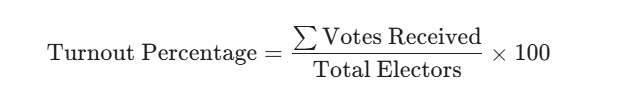

In [45]:
import re

# 1. Use Regex to remove ONLY the trailing code (e.g., "(01)")
# This keeps tags like (ST) or (SC) intact for a perfect match
def clean_pc_name(name):
    return re.sub(r'\s*\(\d+\)$', '', str(name)).upper().strip()

election_constituency_summary['constitution_clean'] = (
    election_constituency_summary['Constituency Name & Code'].apply(clean_pc_name)
)

# 2. Re-create and push the lookup table
elector_lookup_2024 = election_constituency_summary[[
    'standardized_state', 
    'constitution_clean', 
    'electors_clean'
]].drop_duplicates()

elector_lookup_2024['year_int'] = 2024

elector_lookup_2024.to_sql(
    name='temp_electors_2024', 
    con=engine, 
    if_exists='replace', 
    index=False
)

print("Fixed 2024 elector lookup pushed to MySQL.")

Fixed 2024 elector lookup pushed to MySQL.


In [47]:
import re

# This regex finds a space, followed by brackets containing only digits, at the end of the line
# Example: "ARAKU (ST) (1)" -> "ARAKU (ST)"
# Example: "AMETHI (30)" -> "AMETHI"
def clean_pc_name_v2(name):
    return re.sub(r'\s*\(\d+\)$', '', str(name)).upper().strip()

# Apply the new logic
election_constituency_summary['constitution_clean'] = (
    election_constituency_summary['Constituency Name & Code'].apply(clean_pc_name_v2)
)

# Re-create and push the lookup table to MySQL
elector_lookup_2024 = election_constituency_summary[[
    'standardized_state', 
    'constitution_clean', 
    'electors_clean'
]].drop_duplicates()

elector_lookup_2024['year_int'] = 2024

elector_lookup_2024.to_sql(
    name='temp_electors_2024', 
    con=engine, 
    if_exists='replace', 
    index=False
)

print("Refined 2024 lookup (keeping ST/SC tags) pushed to MySQL.")

Refined 2024 lookup (keeping ST/SC tags) pushed to MySQL.


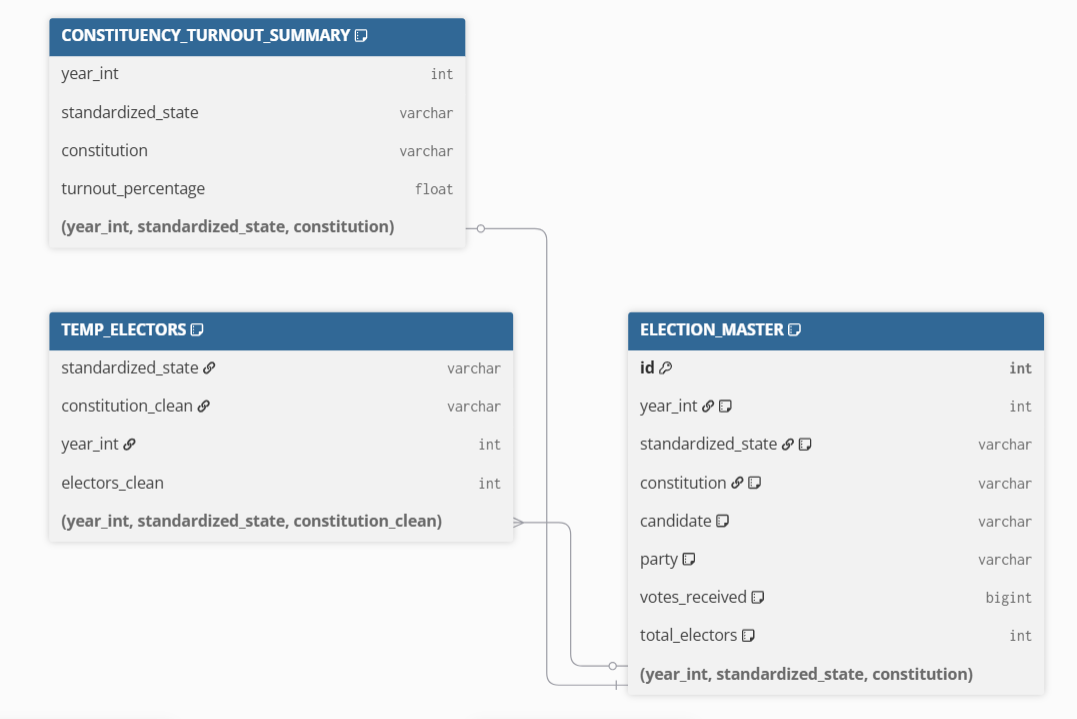